In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/thyroid-disease-data/Thyroid_Diff.csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('/kaggle/input/thyroid-disease-data/Thyroid_Diff.csv')

In [4]:
data.head(10)

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No
5,52,M,Yes,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Indeterminate,No
6,41,F,No,Yes,No,Clinical Hyperthyroidism,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
7,46,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
8,51,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
9,40,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 non-null    ob

### Observation
1. there are no null values in the data
2. Only age is integer type other are object type


In [6]:
data.columns

Index(['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
       'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology',
       'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred'],
      dtype='object')


1. age - Age of the patient (int)<br>
2. sex - Sex the patient identifies with (str)<br>
3. on_thyroxine - Whether patient is on thyroxine (bool)<br>
4. query_on_thyroxine - Whether patient is querying about thyroxine (bool)<br>
5. on_antithyroid_meds - Whether patient is on antithyroid medications (bool)<br>
6. sick - Whether patient is sick (bool)<br>
7. pregnant - Whether patient is pregnant (bool)<br>
8. thyroid_surgery - Whether patient has undergone thyroid surgery (bool)<br>
9. I131_treatment - Whether patient is undergoing I131 treatment (bool)<br>
10. query_hypothyroid - Whether patient believes they have hypothyroid (bool)<br>
11. query_hyperthyroid - Whether patient believes they have hyperthyroid (bool)<br>
12. lithium - Whether patient is on lithium (bool)<br>
13. goitre - Whether patient has goitre (bool)<br>
14. tumor - Whether patient has a tumor (bool)<br>
15. hypopituitary - Whether patient has hypopituitary (float)<br>
16. psych - Whether patient has psych (bool)<br>
17. TSH_measured - Whether TSH was measured in the blood (bool)<br>
18. TSH - TSH level in blood from lab work (float)<br>
19. T3_measured - Whether T3 was measured in the blood (bool)<br>
20. T3 - T3 level in blood from lab work (float)<br>
21. TT4_measured - Whether TT4 was measured in the blood (bool)<br>
22. TT4 - TT4 level in blood from lab work (float)<br>
23. T4U_measured - Whether T4U was measured in the blood (bool)<br>
24. T4U - T4U level in blood from lab work (float)<br>
25. FTI_measured - Whether FTI was measured in the blood (bool)<br>
26. FTI - FTI level in blood from lab work (float)<br>
27. TBG_measured - Whether TBG was measured in the blood (bool)<br>
28. TBG - TBG level in blood from lab work (float)<br>
29. referral_source - Referral source (str)<br>
30. target - Hyperthyroidism medical diagnosis (str)<br>
31. patient_id - Unique ID of the patient (str)<br>

In [7]:
for i in data.columns:
    print(data[i])
    print("*"*35)
    print(data[i].unique())

0      27
1      34
2      30
3      62
4      62
       ..
378    72
379    81
380    72
381    61
382    67
Name: Age, Length: 383, dtype: int64
***********************************
[27 34 30 62 52 41 46 51 40 75 59 49 50 76 42 44 43 36 70 60 33 26 37 55
 31 45 20 38 29 25 21 23 24 35 54 22 69 28 17 73 18 39 57 66 32 47 56 63
 19 67 72 61 68 48 81 53 58 80 79 65 15 82 71 64 78]
0      F
1      F
2      F
3      F
4      F
      ..
378    M
379    M
380    M
381    M
382    M
Name: Gender, Length: 383, dtype: object
***********************************
['F' 'M']
0       No
1       No
2       No
3       No
4       No
      ... 
378    Yes
379    Yes
380    Yes
381    Yes
382    Yes
Name: Smoking, Length: 383, dtype: object
***********************************
['No' 'Yes']
0       No
1      Yes
2       No
3       No
4       No
      ... 
378    Yes
379     No
380    Yes
381    Yes
382     No
Name: Hx Smoking, Length: 383, dtype: object
***********************************
['No' 'Yes']
0    

In [8]:
print(data['Age'].max())
print(data['Age'].min())

82
15


The highest age of thyroid is 82 and the  lowest age is 15

In [9]:
data.head(1)

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


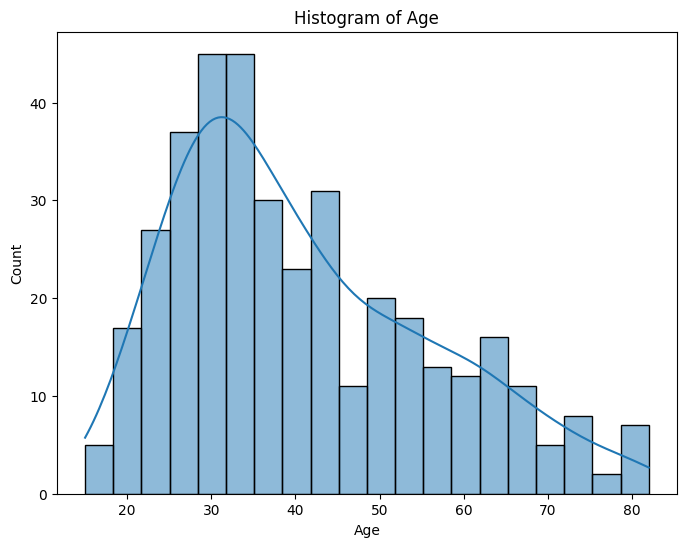

In [10]:
# Visualization 1: Histogram of Age
plt.figure(figsize=(8, 6))
sns.histplot(data['Age'], bins=20, kde=True)
plt.title('Histogram of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

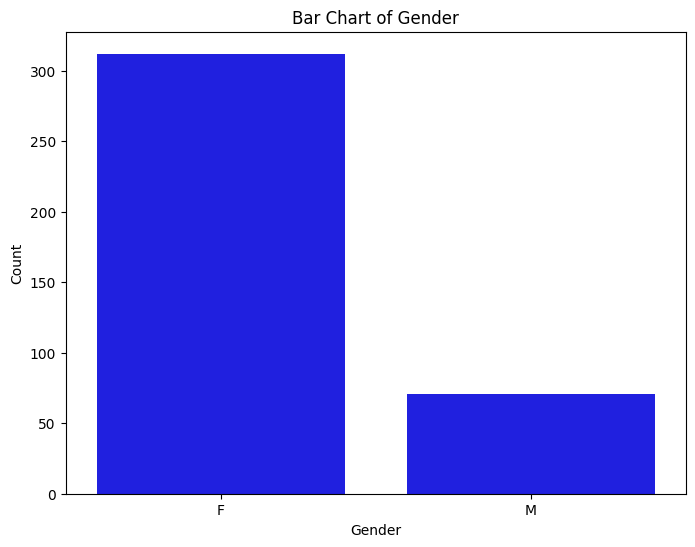

In [11]:
# Visualization 2: Bar Chart of Gender
plt.figure(figsize=(8, 6))
sns.countplot(x='Gender', data=data,color = 'blue')
plt.title('Bar Chart of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

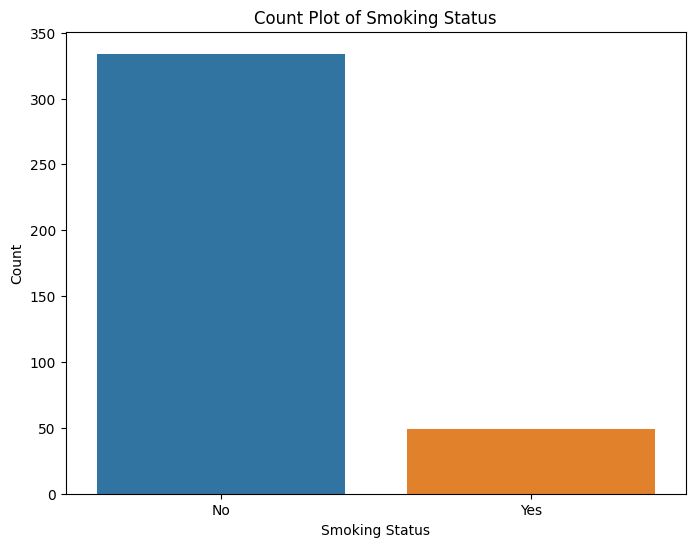

In [12]:
# Visualization 3: Count Plot of Smoking Status
plt.figure(figsize=(8, 6))
sns.countplot(x='Smoking', data=data)
plt.title('Count Plot of Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Count')
plt.show()

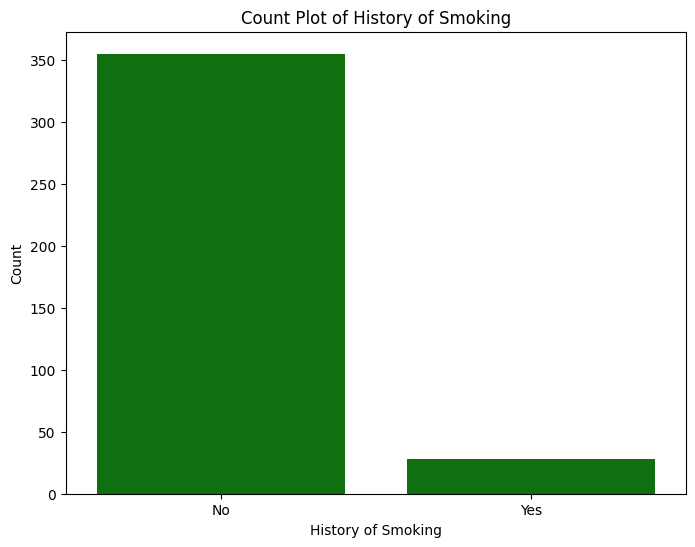

In [13]:
# Visualization 4: Count Plot of History of Smoking
plt.figure(figsize=(8, 6))
sns.countplot(x='Hx Smoking', data=data, color='green')  # Specify color as 'green'
plt.title('Count Plot of History of Smoking')
plt.xlabel('History of Smoking')
plt.ylabel('Count')
plt.show()


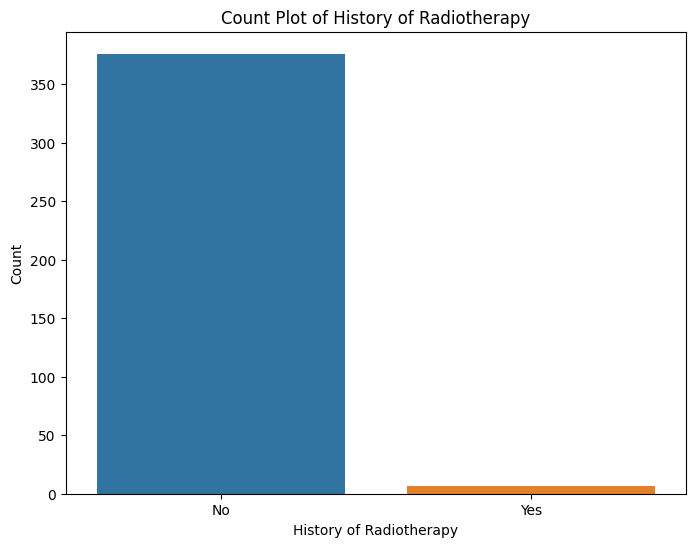

In [14]:
# Visualization 5: Count Plot of History of Radiotherapy
plt.figure(figsize=(8, 6))
sns.countplot(x='Hx Radiothreapy', data=data)
plt.title('Count Plot of History of Radiotherapy')
plt.xlabel('History of Radiotherapy')
plt.ylabel('Count')
plt.show()

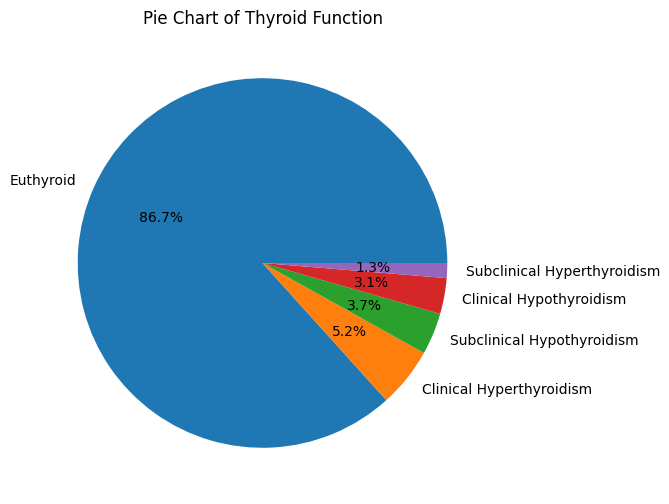

In [15]:
# Visualization 6: Pie Chart of Thyroid Function
plt.figure(figsize=(8, 6))
data['Thyroid Function'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Pie Chart of Thyroid Function')
plt.ylabel('')
plt.show()


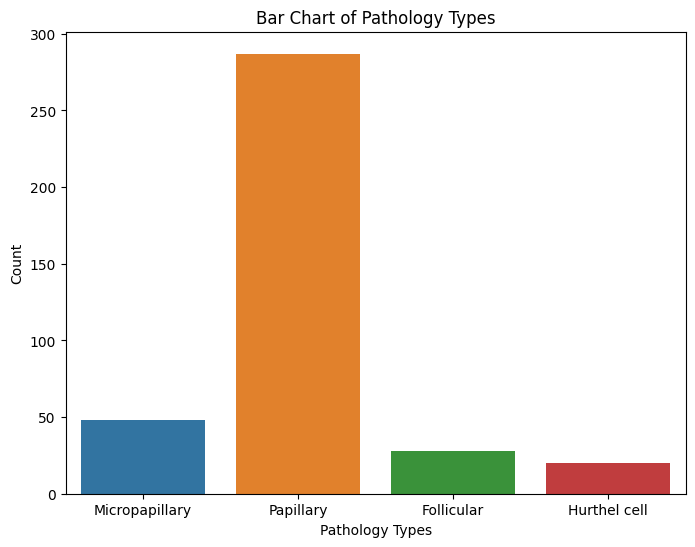

In [16]:
# Visualization 7: Bar Chart of Pathology Types
plt.figure(figsize=(8, 6))
sns.countplot(x='Pathology', data=data)
plt.title('Bar Chart of Pathology Types')
plt.xlabel('Pathology Types')
plt.ylabel('Count')
plt.show()


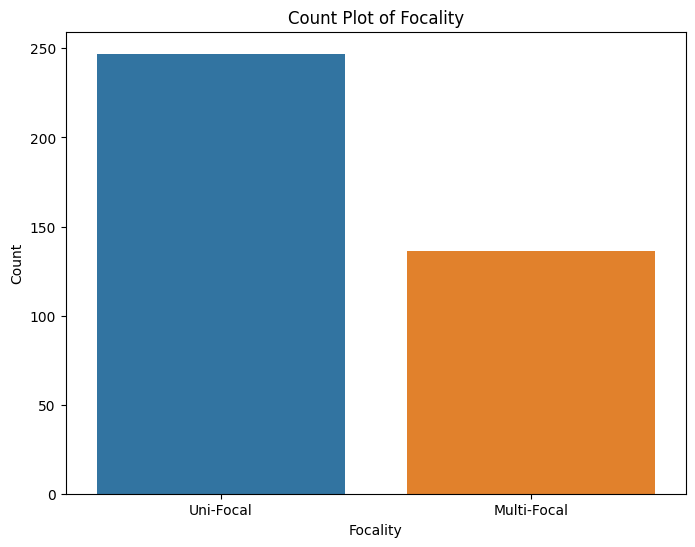

In [17]:
# Visualization 8: Count Plot of Focality
plt.figure(figsize=(8, 6))
sns.countplot(x='Focality', data=data)
plt.title('Count Plot of Focality')
plt.xlabel('Focality')
plt.ylabel('Count')
plt.show()

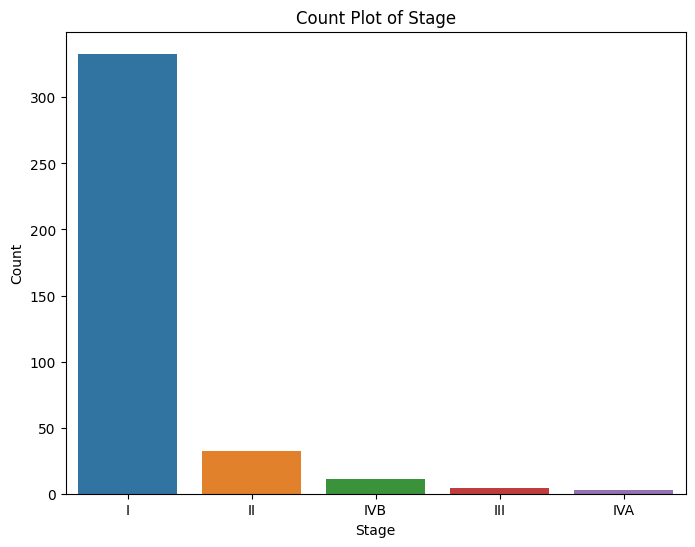

In [18]:
# Visualization 9: Count Plot of Stage
plt.figure(figsize=(8, 6))
sns.countplot(x='Stage', data=data)
plt.title('Count Plot of Stage')
plt.xlabel('Stage')
plt.ylabel('Count')
plt.show()

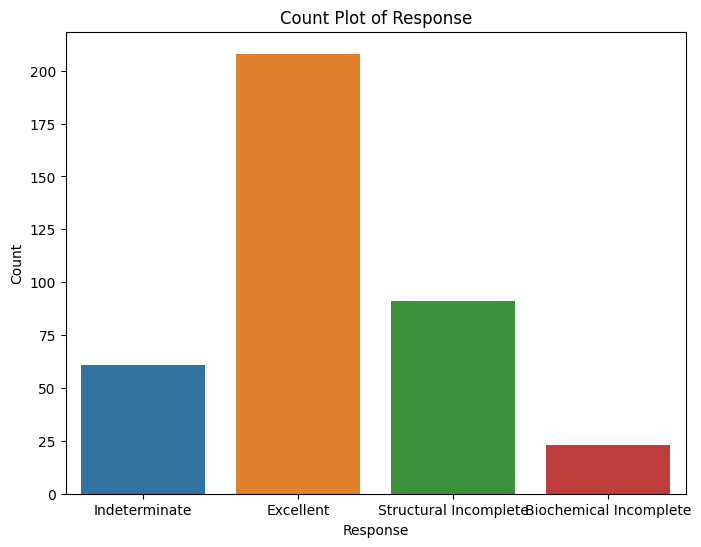

In [19]:
# Visualization 10: Count Plot of Response
plt.figure(figsize=(8, 6))
sns.countplot(x='Response', data=data)
plt.title('Count Plot of Response')
plt.xlabel('Response')
plt.ylabel('Count')
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import preprocessing

In [21]:
# Handle categorical variables (if any)
#data = pd.get_dummies(data)  # Convert categorical variables into dummy/indicator variables


In [22]:
data.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [23]:
# Separate features (X) and target variable (y)
X = data.drop('Response', axis=1)  # Assuming 'Response' is the target variable
y = data['Response']

In [24]:
#Handle categorical variables (if any)
X= pd.get_dummies(X)  # Convert categorical variables into dummy/indicator variables


In [25]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [26]:
# Initialize the Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=42)

# Train the classifier
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [27]:
# Predict on the test set
y_pred = clf.predict(X_test)



In [28]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)



Accuracy: 0.7532467532467533


In [29]:
# Generate classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
                        precision    recall  f1-score   support

Biochemical Incomplete       0.40      0.67      0.50         3
             Excellent       0.83      0.83      0.83        48
         Indeterminate       0.30      0.30      0.30        10
 Structural Incomplete       0.93      0.81      0.87        16

              accuracy                           0.75        77
             macro avg       0.62      0.65      0.62        77
          weighted avg       0.77      0.75      0.76        77

